# Actionability Audit


In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [155]:
df_out = pd.read_csv("../output/sentences_actionability.csv")
#show just sentence column and actionability_probability
pd.set_option("display.max_colwidth", None)   # show full text in cells
pd.set_option("display.max_rows", 60)         # optional
pd.set_option("display.width", 0)             # auto-detect width
df_out[["sentence", "actionability_probability"]].head().sort_values("actionability_probability", ascending=True)

,sentence,actionability_probability
1,Comienza a revertirse el déficit pluviométrico que dejó el invierno en esta región.,0.0000
3,"Su desplazamiento favoreció el desarrollo de tormentas aisladas severas en la región pampeana, produciendo luego un moderado descenso de temperaturas.",0.0000
2,Importantes cambios en las condiciones de tiempo se produjeron en las últimas jornadas en Argentina con el avance de un frente frío.,0.0351
0,"El noreste argentino sería el sector más afectado, con precipitaciones que podrían superar los 200mm en esta última semana del mes.",0.0877
4,"El descenso térmico se sintió de manera más marcada en estas últimas horas en el norte argentino, luego de un fin de semana con registros de hasta 42°C.",0.0877


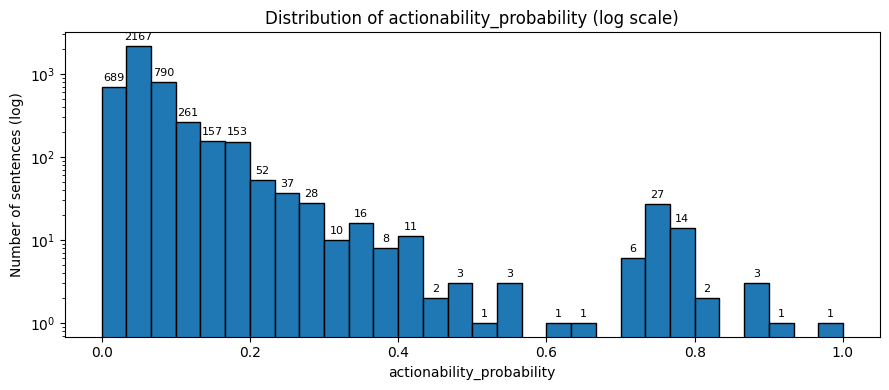

In [140]:

# log-scaled histogram of actionability_probability with counts on top of bars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "actionability_probability"
if col not in df_out.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df_out.columns)}")

s = pd.to_numeric(df_out[col], errors="coerce").dropna()

fig, ax = plt.subplots(figsize=(9, 4))

counts, bins, patches = ax.hist(s, bins=30, edgecolor="black")

ax.set_yscale("log")
ax.set_title("Distribution of actionability_probability (log scale)")
ax.set_xlabel("actionability_probability")
ax.set_ylabel("Number of sentences (log)")

# label each bar with its count (skip zeros)
for c, p in zip(counts, patches):
    if c <= 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f"{int(c)}",
        (x, y),
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()



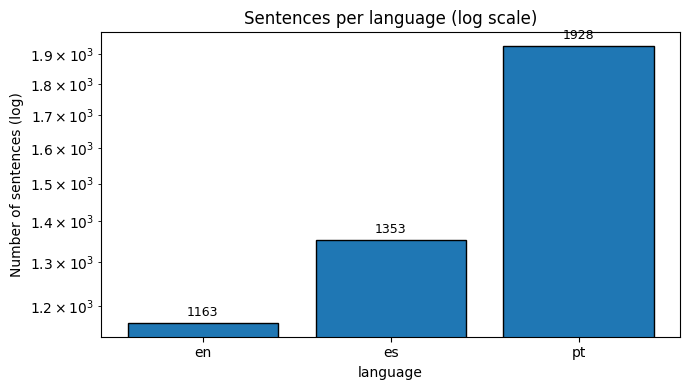

In [141]:

# bar chart: number of sentences per language (log scale) with counts on top
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp = dfp.dropna(subset=[col, lang_col])

counts_by_lang = dfp[lang_col].astype(str).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts_by_lang.index.tolist(), counts_by_lang.values.tolist(), edgecolor="black")

ax.set_yscale("log")
ax.set_title("Sentences per language (log scale)")
ax.set_xlabel("language")
ax.set_ylabel("Number of sentences (log)")

# labels on top of bars
for b in bars:
    h = b.get_height()
    if h <= 0:
        continue
    ax.annotate(
        f"{int(h)}",
        (b.get_x() + b.get_width() / 2, h),
        ha="center",
        va="bottom",
        fontsize=9,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()


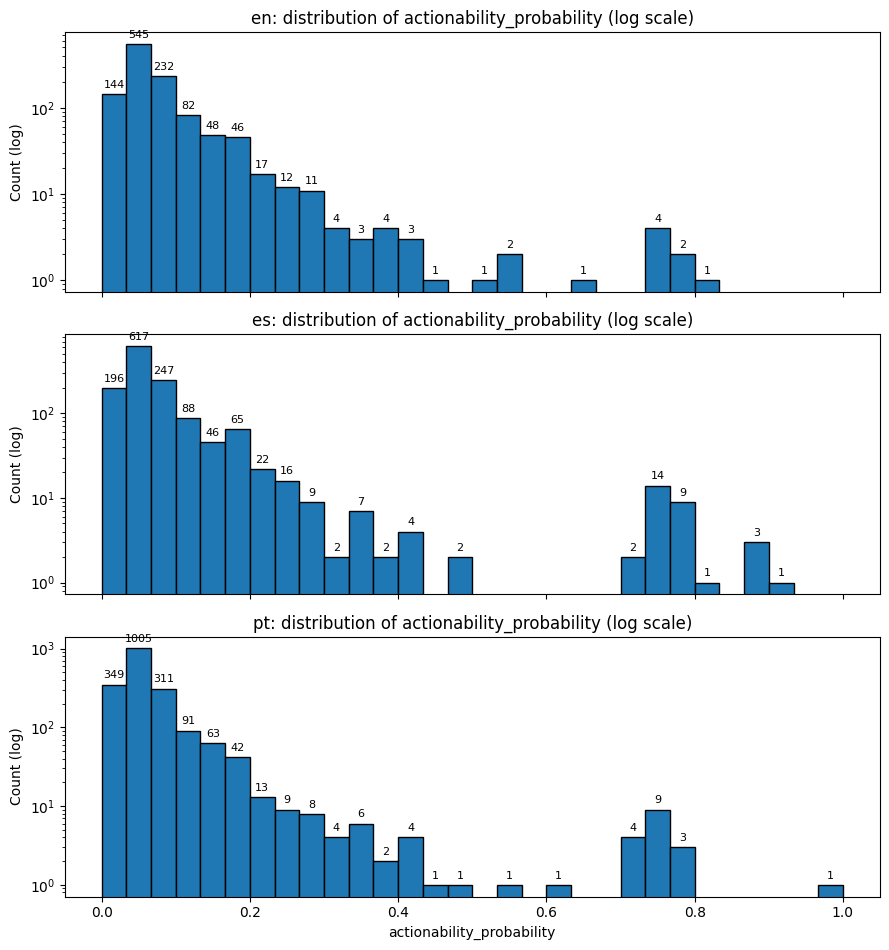

In [142]:
# subplots: one histogram per language for actionability_probability (log y) with counts on bars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

langs = sorted(dfp[lang_col].unique().tolist())
if not langs:
    raise ValueError("No languages found.")

# Use shared bins across languages so plots are comparable
xmin = float(dfp[col].min())
xmax = float(dfp[col].max())
if xmin == xmax:
    # degenerate case: all probs equal
    bins = np.linspace(max(0.0, xmin - 1e-6), min(1.0, xmax + 1e-6), 2)
else:
    bins = np.linspace(xmin, xmax, 31)  # 30 bins

fig, axes = plt.subplots(nrows=len(langs), ncols=1, figsize=(9, 3.2 * len(langs)), sharex=True)
if len(langs) == 1:
    axes = [axes]

for ax, lang in zip(axes, langs):
    s = dfp.loc[dfp[lang_col] == lang, col]

    counts, _, patches = ax.hist(s, bins=bins, edgecolor="black")
    ax.set_yscale("log")
    ax.set_title(f"{lang}: distribution of {col} (log scale)")
    ax.set_ylabel("Count (log)")

    # label counts on bars
    for c, p in zip(counts, patches):
        if c <= 0:
            continue
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(
            f"{int(c)}",
            (x, y),
            ha="center",
            va="bottom",
            fontsize=8,
            textcoords="offset points",
            xytext=(0, 3),
        )

axes[-1].set_xlabel(col)

plt.tight_layout()
plt.show()

### Investigating False Positives 

In [143]:

# top 30 most actionable sentences (highest actionability_probability)
import pandas as pd

prob_col = "actionability_probability"
text_col_candidates = ["sentence", "text", "clean_text", "original_sentence"]

for c in [prob_col, "language"]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# pick a text column that exists
text_col = next((c for c in text_col_candidates if c in df_out.columns), None)
if text_col is None:
    raise KeyError(
        f"No sentence/text column found. Tried {text_col_candidates}. "
        f"Available columns: {list(df_out.columns)}"
    )

dfp = df_out[[prob_col, "language", text_col]].copy()
dfp[prob_col] = pd.to_numeric(dfp[prob_col], errors="coerce")
dfp = dfp.dropna(subset=[prob_col, text_col])

top = dfp.sort_values(prob_col, ascending=False).head(30).reset_index(drop=True)

for i, r in top.iterrows():
    print(f"{i+1:02d} | lang={r['language']} | p={r[prob_col]:.4f}")
    print(r[text_col])
    print()

01 | lang=pt | p=1.0000
Defesa Civil faz novo recolhimento de fios soltos em vias públicasCidadeA ação foi realizada em diversos bairros, como Tropical, Atlântica, Colina Verde, Alphaville e Residencial PanoramaNos últimos dias a Coordenadoria Municipal de Proteção e Defesa Civil de Penápolis realizou uma série de recolhimentos de fios e cabos soltos em vias públicas e postes de energia da cidade, especialmente como medida de prevenção a acidentes.

02 | lang=es | p=0.9123
Se recomienda continuar atentos a los pobladores de zonas ribereñas de los municipios Tierra

03 | lang=es | p=0.8947
Por ello, las autoridades capitalinas compartieron recomendaciones para cuidarse del frío: usar crema hidratante para proteger tu piel de las bajas temperaturas, consumir agua y alimentos con abundante vitamina C, además de acudir al médico en caso de que se tengan síntomas de gripe o algún malestar relacionado con enfermedades respiratorias.¿Cuáles serán las afectaciones del frente frío número 31 en 

In [144]:

import pandas as pd

prob_col = "actionability_probability"
lang_col = "language"
text_col = "sentence"  # change if your real text col is different

dfp = df_out[[prob_col, lang_col, text_col]].copy()
dfp[prob_col] = pd.to_numeric(dfp[prob_col], errors="coerce")
dfp[text_col] = dfp[text_col].astype(str)

top = dfp.sort_values(prob_col, ascending=False).head(30)

display(top.assign(char_len=top[text_col].str.len())[[lang_col, prob_col, "char_len", text_col]])


,language,actionability_probability,char_len,sentence
1260,pt,1.0000,428,"Defesa Civil faz novo recolhimento de fios soltos em vias públicasCidadeA ação foi realizada em diversos bairros, como Tropical, Atlântica, Colina Verde, Alphaville e Residencial PanoramaNos últimos dias a Coordenadoria Municipal de Proteção e Defesa Civil de Penápolis realizou uma série de recolhimentos de fios e cabos soltos em vias públicas e postes de energia da cidade, especialmente como medida de prevenção a acidentes."
2157,es,0.9123,92,Se recomienda continuar atentos a los pobladores de zonas ribereñas de los municipios Tierra
2527,es,0.8947,474,"Por ello, las autoridades capitalinas compartieron recomendaciones para cuidarse del frío: usar crema hidratante para proteger tu piel de las bajas temperaturas, consumir agua y alimentos con abundante vitamina C, además de acudir al médico en caso de que se tengan síntomas de gripe o algún malestar relacionado con enfermedades respiratorias.¿Cuáles serán las afectaciones del frente frío número 31 en México?El desfile de frentes fríos continúa sobre territorio nacional."
2872,es,0.8947,798,"Asimismo, en municipios del oriente del Estado de México también se registraron lluvias fuertes y tormentas eléctricas.¿Qué hacer ante las fuertes lluvias?La Secretaría de Gestión Integral de Riesgos y Protección Civil CDMX (SGIRPC) informó que en caso de lluvias fuertes se deben seguir estas recomendaciones:- Cerrar puertas y ventanas- No intentar cruzar las calles con corrientes de agua- Portar un impermeable que, de preferencia, tenga reflejante- Mantenerse informado¿Cómo protegerse de las tormentas eléctricas?De acuerdo con Protección Civil del Gobierno federal, una tormenta eléctrica es una nube capaz de producir un trueno audible, debido al choque de dos masas de aire con diferentes temperaturas, que puede producir una serie de lluvias, vientos, relámpagos, truenos y hasta granizo."
2551,es,0.8772,210,"Las recomendaciones de las autoridades de la Ciudad de México ante las fuertes lluvias son cerrar ventanas y puertas, no caminar por corrientes de agua y usar impermeables con reflejantes si andas en bicicleta."
3977,en,0.8246,34,The safety of children at schools.
2719,es,0.8070,538,"En ese sentido, las autoridades recomendaron mantener la comunicación entre empleados y patrones, a fin de evaluar la posibilidad de hacer home office, sobre todo si los traslados son largos y arriesgan al trabajador. 'La Secretaría de Trabajo y Fomento al Empleo hace un llamado a los empleadores a ser comprensivos con las trabajadoras y trabajadores que enfrentan dificultades para llegar a sus centros de trabajo... El diálogo y la empatía hacen la diferencia', explicó la dependencia capitalina.¿Home office ante las fuertes lluvias?"
1052,pt,0.7895,101,Também não é recomendado estacionar veículos próximos a torres de transmissão e placas de propaganda.
2596,es,0.7895,633,"Recomendaciones para evitar golpes de calorLas autoridades emitieron una serie de recomendaciones para evitar un golpe de calor:- Utilizar lentes de sol y gorra al salir a la calle.- Usar bloqueador solar.- No exponerse al sol por tiempo prolongado.- Mantenerse hidratado.- Vestir con ropa de colores claros al salir de casa.- No descuidar a grupos vulnerables.- Evitar comer en la vía pública.¿Por qué hace tanto calor en México?En entrevista con El Financiero, Ángel Meulenert, especialista en meteorología y climatología, explicó las razones por las que ha habido altas temperaturas y escasez de lluvias en el territorio nacional."
749,pt,0.7895,506,"CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileira (FAB) enviou dois helicópteros, na noite desta terça-feira (30/4), para auxiliar no resgate 

#### add_advice_flag
Testing function add_advice_flag 

In [145]:
# assumes df_out already loaded
text_col = "sentence"
lang_col = "language"
score_col = "actionability_probability"

for c in [text_col, lang_col, score_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

mask_pt = df_out[lang_col].astype(str).str.strip().str.lower().eq("pt")
mask_word = df_out[text_col].astype(str).str.contains(
    r"\b(recomenda|recomendado|recomendação|recomendar|recomendo|recomendava|recomendou|recomende)\b",
    flags=re.IGNORECASE,
    regex=True,
)

hits = df_out.loc[mask_pt & mask_word, [lang_col, score_col, text_col]].copy()
hits[score_col] = pd.to_numeric(hits[score_col], errors="coerce")
hits = hits.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits)} Portuguese sentences containing 'recomend*':\n")
for i, r in hits.iterrows():
    print(f"{i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

# save sentences to a list
portuguese_sentences = hits[text_col].astype(str).tolist()

Found 10 Portuguese sentences containing 'recomend*':

001 | p=0.7895 | CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileira (FAB) enviou dois helicópteros, na noite desta terça-feira (30/4), para auxiliar no resgate dos atingidos pelas enchentes na região de Santa Maria, no Rio Grande do Sul.
002 | p=0.7895 | Também não é recomendado estacionar veículos próximos a torres de transmissão e placas de propaganda.
003 | p=0.7895 | Em caso de rajadas de vento, o instituto recomenda que as pessoas não se abriguem debaixo de árvores e não estacionem veículos próximos a torres de transmissão e placas de propaganda.
004 | p=0.7368 | O Inmet recomenda que, em caso de rajadas de ventos, as pessoas não se abriguem deba

/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_73999/3786657601.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_word = df_out[text_col].astype(str).str.contains(


In [146]:


# assumes df_out already loaded
text_col = "sentence"
lang_col = "language"
score_col = "actionability_probability"

for c in [text_col, lang_col, score_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# -------------------------
# EN: recommend/suggest/advise (print with score)
# -------------------------
mask_en = df_out[lang_col].astype(str).str.strip().str.lower().eq("en")
mask_en_word = df_out[text_col].astype(str).str.contains(
    r"\b(?:recommend|recommends|recommended|recommending|suggests|advises|urge|urges|urged|urging)\b",
    flags=re.IGNORECASE,
    regex=True,
)

hits_en = df_out.loc[mask_en & mask_en_word, [lang_col, score_col, text_col]].copy()
hits_en[score_col] = pd.to_numeric(hits_en[score_col], errors="coerce")
hits_en = hits_en.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits_en)} English sentences containing recommend*/suggests/advises:\n")
for i, r in hits_en.iterrows():
    print(f"EN {i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

print("\n" + "-" * 80 + "\n")

# -------------------------
# ES: recomend* (print with score)
# -------------------------
mask_es = df_out[lang_col].astype(str).str.strip().str.lower().eq("es")
mask_es_word = df_out[text_col].astype(str).str.contains(
    r"\brecomend",
    flags=re.IGNORECASE,
    regex=True,
)

hits_es = df_out.loc[mask_es & mask_es_word, [lang_col, score_col, text_col]].copy()
hits_es[score_col] = pd.to_numeric(hits_es[score_col], errors="coerce")
hits_es = hits_es.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits_es)} Spanish sentences containing 'recomend*':\n")
for i, r in hits_es.iterrows():
    print(f"ES {i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

Found 5 English sentences containing recommend*/suggests/advises:

EN 001 | p=0.7719 | B.C. residents urged not to panic-buy as bare shelves fuel food security angstFlooding has put pressure on B.C.'s dairy, chicken, and egg industry; province says there's enough foodProvincial leaders are urging British Columbians not to hoard food and groceries as disruptions to B.C.'s farm industry and supply chains from historic rain and flooding fuels angst amid consumers.
EN 002 | p=0.7719 | However, for many owners there's no requirement they raise their properties to the heights FEMA recommends.
EN 003 | p=0.7368 | However, for many owners there's no requirement they raise their properties to the heights FEMA recommends.
EN 004 | p=0.7368 | Three other unit leaders who were not with the transport have also been recommended for reprimands.
EN 005 | p=0.7368 | However, for many owners there's no requirement they raise their properties to the heights FEMA recommends.

-----------------------------

In [147]:

import re

text_col = "sentence"
lang_col = "language"

for c in [text_col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# --- English: suggests OR advises ---
mask_en = df_out[lang_col].astype(str).str.strip().str.lower().eq("en")
mask_en_word = df_out[text_col].astype(str).str.contains(r"\b(?:suggests|advises)\b", flags=re.IGNORECASE, regex=True)

hits_en = df_out.loc[mask_en & mask_en_word, [lang_col, text_col]].copy()
print(f"Found {len(hits_en)} English sentences containing 'suggests' or 'advises':\n")
for i, s in enumerate(hits_en[text_col].astype(str).tolist(), start=1):
    print(f"EN {i:03d} | {s}")

print("\n" + "-" * 80 + "\n")

# --- Spanish: sugiere OR aconseja ---
mask_es = df_out[lang_col].astype(str).str.strip().str.lower().eq("es")
mask_es_word = df_out[text_col].astype(str).str.contains(r"\b(?:sugiere|aconseja)\b", flags=re.IGNORECASE, regex=True)

hits_es = df_out.loc[mask_es & mask_es_word, [lang_col, text_col]].copy()
print(f"Found {len(hits_es)} Spanish sentences containing 'sugiere' or 'aconseja':\n")
for i, s in enumerate(hits_es[text_col].astype(str).tolist(), start=1):
    print(f"ES {i:03d} | {s}")

Found 0 English sentences containing 'suggests' or 'advises':


--------------------------------------------------------------------------------

Found 2 Spanish sentences containing 'sugiere' or 'aconseja':

ES 001 | Según el informe, el volumen de desapariciones en la capital del país sugiere un 'deterioro en las capacidades de las fiscalías y un recrudecimiento del conflicto entre grupos criminales locales y nuevas organizaciones'.
ES 002 | Te has suscrito a notificacionesConfigura y elige tus preferenciasLas alcaldías donde se activó la alerta amarilla son: Álvaro Obregón, Benito Juárez, Coyoacán, Cuauhtémoc, Cuajimalpa, Iztacalco, Iztapalapa, Magdalena Contreras, Tlalpan y Venustiano CarranzaSe sugiere permanecer atento a las actualizaciones meteorológicas.


# Investigation Bias in actionability detection by language 
Distribution of actionability and potential bias in detection by language

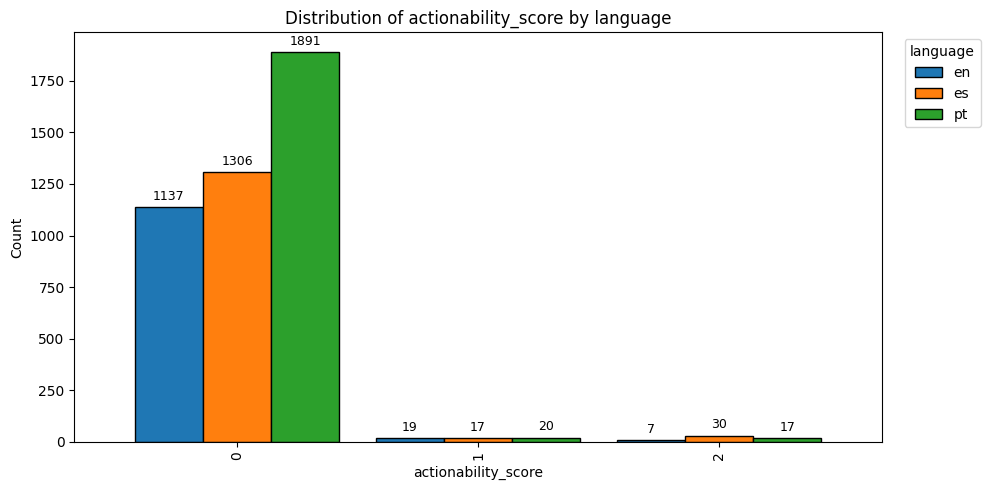

In [148]:

# Distribution of actionability_score (0/1/2) by language, with counts on bars

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

score_col = "actionability_score"
lang_col = "language"

for c in [score_col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[score_col, lang_col]].copy()
dfp[score_col] = pd.to_numeric(dfp[score_col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[score_col, lang_col])

# Keep only scores 0/1/2
dfp = dfp[dfp[score_col].isin([0, 1, 2])].copy()
dfp[score_col] = dfp[score_col].astype(int)

# counts per score per language (rows=score, cols=language)
ct = (
    dfp.groupby([score_col, lang_col])
       .size()
       .unstack(lang_col)
       .fillna(0)
       .astype(int)
)

# Ensure rows are ordered 0,1,2 even if missing
ct = ct.reindex([0, 1, 2], fill_value=0)

ax = ct.plot(kind="bar", figsize=(10, 5), width=0.85, edgecolor="black")

ax.set_title("Distribution of actionability_score by language")
ax.set_xlabel("actionability_score")
ax.set_ylabel("Count")
ax.legend(title="language", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v)}" if v > 0 else "" for v in container.datavalues], padding=3, fontsize=9)

plt.show()

In [152]:
#read final cv
df_final = pd.read_csv("../output/enriched.csv")
df_final[["actionability_percentage","country","scope","dominant_frame"]].head(30)

,actionability_percentage,country,scope,dominant_frame
0,0.00,Argentina,local,impact
1,0.00,Argentina,local,accountability
2,0.00,Bolivia (Plurinational State of),local,impact
3,0.00,Bolivia (Plurinational State of),local,response
4,0.00,Bolivia (Plurinational State of),local,response
5,0.00,Brazil,national,response
6,0.00,Brazil,local,accountability
7,0.00,Brazil,local,impact
8,12.50,Brazil,local,response
9,0.00,Brazil,local,impact


### Investigation false negatives 
(still have not done this part)

In [158]:
df_out[["sentence", "actionability_probability"]].nsmallest(
    20, "actionability_probability"
)

,sentence,actionability_probability
1,Comienza a revertirse el déficit pluviométrico que dejó el invierno en esta región.,0.0
3,"Su desplazamiento favoreció el desarrollo de tormentas aisladas severas en la región pampeana, produciendo luego un moderado descenso de temperaturas.",0.0
6,"En la región central relativas altas presiones estarán presentes al menos hasta el miércoles, prevaleciendo el buen tiempo a pesar de la nubosidad pasajera.",0.0
9,"En tal sentido, el Servicio Meteorológico Nacio",0.0
15,"Registros pluviométricos extraoficiales, indican precipitaciones de hasta 130mm en la provincia.",0.0
45,"No Rio de Janeiro, foi decretado situação de emergência na semana passada depois q",0.0
52,"No dia 15 de maio de 2018, o pr",0.0
58,Também acabou tombando outro poste na Rua América.,0.0
59,"O aposentado contou que a chuva não foi volumosa, mas os ventos eram fortes suficientes para provocar estragos, como ocorreu.",0.0
61,"Durou no máximo dez minutos e fez todo esse estrago', relatou.",0.0


## Audit by article 

### Investigating Stability in results and relevance of overall actionability per article 

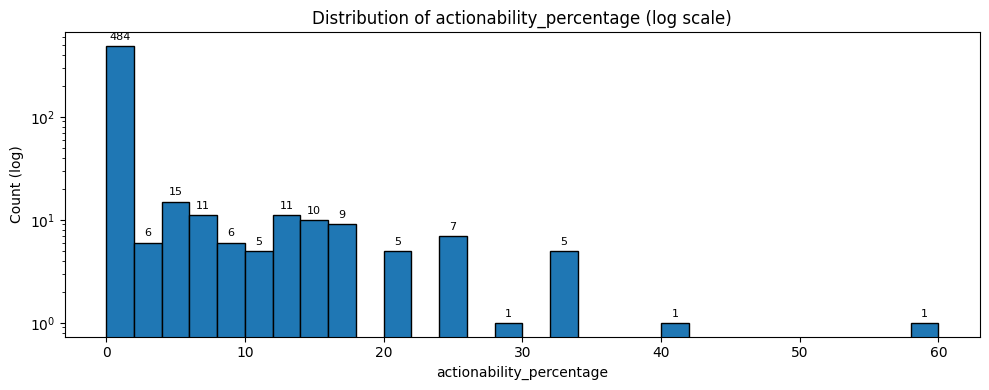

In [153]:
#distrubuiton of actionability percentage 
col = "actionability_percentage"

if col not in df_final.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df_final.columns)}")

s = pd.to_numeric(df_final[col], errors="coerce").dropna()

# If it's 0-1, convert to 0-100 for nicer bins (auto-detect)
if (s.max() <= 1.0) and (s.min() >= 0.0):
    s_plot = s * 100.0
    x_label = "actionability_percentage (%)"
else:
    s_plot = s
    x_label = col

bins = 30  # adjust if needed

fig, ax = plt.subplots(figsize=(10, 4))

counts, bin_edges, patches = ax.hist(s_plot, bins=bins, edgecolor="black")

ax.set_yscale("log")
ax.set_title(f"Distribution of {col} (log scale)")
ax.set_xlabel(x_label)
ax.set_ylabel("Count (log)")

# print counts on top of bars (skip zeros)
for c, p in zip(counts, patches):
    if c <= 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f"{int(c)}",
        (x, y),
        ha="center",
        va="bottom",
        fontsize=8,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()